In [22]:
import numpy as np
import pandas as pd
import shap

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

from lightgbm import LGBMClassifier

plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
df = pd.read_csv("./Particle Physics Event Classification.csv")

print("Shape:", df.shape)

display(df.head())

Shape: (250000, 33)


,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497,0.002653,s
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,1,46.226,0.725,1.158,-999.000,-999.00,-999.000,46.226,2.233584,b
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,1,44.251,2.053,-2.028,-999.000,-999.00,-999.000,44.251,2.347389,b
3,100003,143.905,81.417,80.943,0.414,9.00,-999.000,-999.000,3.310,0.414,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,5.446378,b
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,6.245333,b


In [3]:
print(df.info())

display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   EventId                      250000 non-null  int64  
 1   DER_mass_MMC                 250000 non-null  float64
 2   DER_mass_transverse_met_lep  250000 non-null  float64
 3   DER_mass_vis                 250000 non-null  float64
 4   DER_pt_h                     250000 non-null  float64
 5   DER_deltaeta_jet_jet         250000 non-null  float64
 6   DER_mass_jet_jet             250000 non-null  float64
 7   DER_prodeta_jet_jet          250000 non-null  float64
 8   DER_deltar_tau_lep           250000 non-null  float64
 9   DER_pt_tot                   250000 non-null  float64
 10  DER_sum_pt                   250000 non-null  float64
 11  DER_pt_ratio_lep_tau         250000 non-null  float64
 12  DER_met_phi_centrality       250000 non-null  float64
 13 

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,...,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,224999.500000,-49.023079,49.239819,81.181982,57.895962,-708.416643,-601.237051,-709.356603,2.373100,18.917332,...,209.797178,0.979176,-348.329567,-399.254314,-399.259788,-692.381204,-709.121609,-709.118631,73.064591,1.646767
std,72168.927986,406.345647,35.344886,40.828691,63.655682,454.482458,657.972302,453.019877,0.782911,22.273494,...,126.499506,0.977426,532.962789,489.338286,489.333883,479.875496,453.384624,453.389017,98.015662,1.875103
min,100000.000000,-999.000000,0.000000,6.329000,0.000000,-999.000000,-999.000000,-999.000000,0.208000,0.000000,...,13.678000,0.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,0.000000,0.001502
25%,162499.750000,78.100750,19.241000,59.388750,14.068750,-999.000000,-999.000000,-999.000000,1.810000,2.841000,...,123.017500,0.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,0.000000,0.018636
50%,224999.500000,105.012000,46.524000,73.752000,38.467500,-999.000000,-999.000000,-999.000000,2.491500,12.315500,...,179.739000,1.000000,38.960000,-1.872000,-2.093000,-999.000000,-999.000000,-999.000000,40.512500,1.156188
75%,287499.250000,130.606250,73.598000,92.259000,79.169000,0.490000,83.446000,-4.593000,2.961000,27.591000,...,263.379250,2.000000,75.349000,0.433000,0.503000,33.703000,-2.457000,-2.275000,109.933750,2.404128
max,349999.000000,1192.026000,690.075000,1349.351000,2834.999000,9.000000,4974.979000,16.690000,5.684000,2834.999000,...,2003.976000,3.000000,1120.573000,4.499000,3.141000,721.456000,4.500000,3.142000,1633.433000,7.822543


,missing_count,missing_pct
DER_lep_eta_centrality,177457,70.9828
PRI_jet_subleading_pt,177457,70.9828
DER_mass_jet_jet,177457,70.9828
PRI_jet_subleading_phi,177457,70.9828
PRI_jet_subleading_eta,177457,70.9828
DER_prodeta_jet_jet,177457,70.9828
DER_deltaeta_jet_jet,177456,70.9824
PRI_jet_leading_phi,99913,39.9652
PRI_jet_leading_pt,99913,39.9652
PRI_jet_leading_eta,99913,39.9652


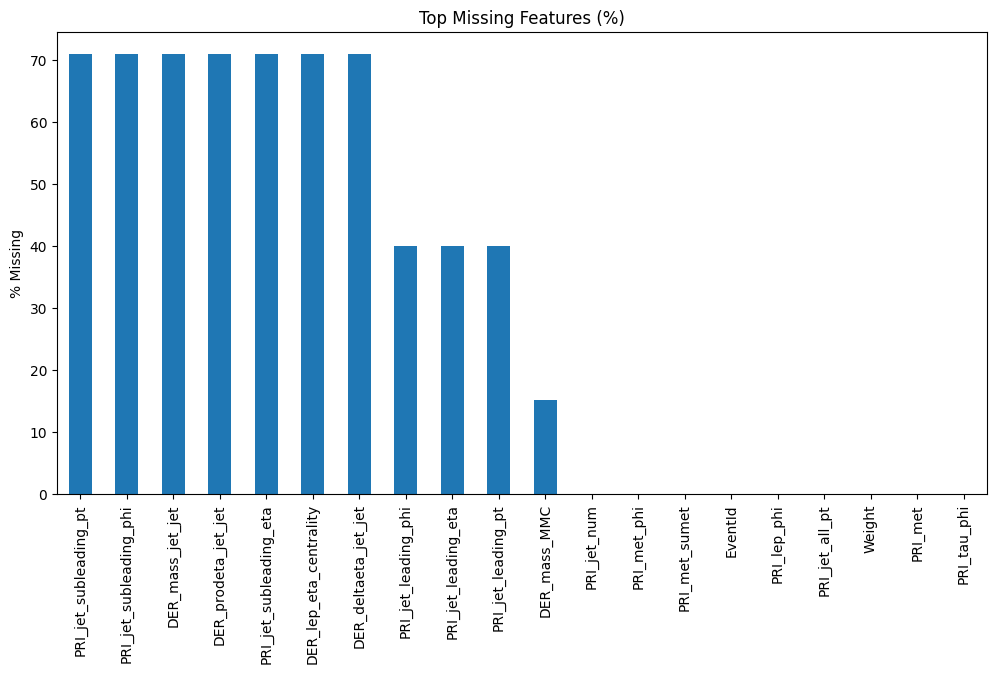

In [34]:
missing_counts = (df == -999).sum()

missing_pct = (
    missing_counts / len(df) * 100
).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct
}).sort_values("missing_pct", ascending=False)

display(missing_df.head(20))

plt.figure(figsize=(12,6))
missing_pct.head(20).plot(kind="bar")
plt.title("Top Missing Features (%)")
plt.ylabel("% Missing")
plt.savefig(
    "/Users/mahdikhosravi/Downloads/missing_values.png",
    bbox_inches="tight"
)
plt.show()

Label
b    164333
s     85667
Name: count, dtype: int64
Label
b    0.657332
s    0.342668
Name: proportion, dtype: float64


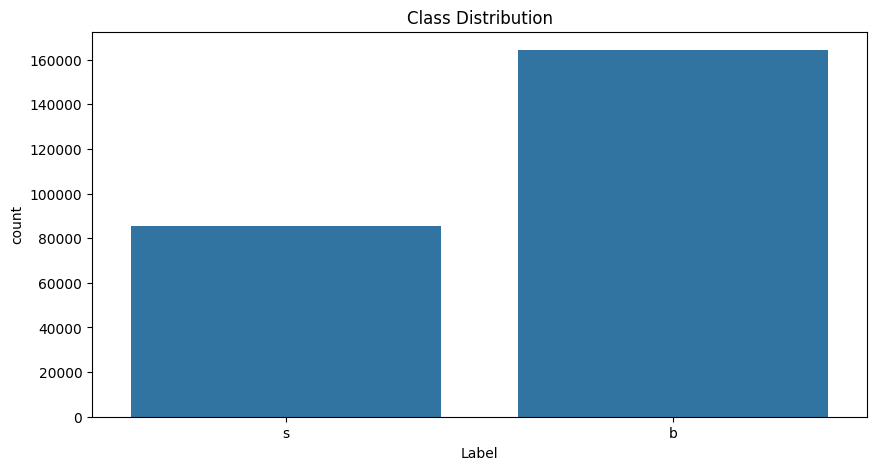

In [35]:
print(df["Label"].value_counts())

print(
    df["Label"].value_counts(normalize=True)
)

sns.countplot(
    data=df,
    x="Label"
)

plt.title("Class Distribution")
plt.savefig(
    "/Users/mahdikhosravi/Downloads/class_distribution.png",
    bbox_inches="tight"
)
plt.show()

count    250000.000000
mean          1.646767
std           1.875103
min           0.001502
25%           0.018636
50%           1.156188
75%           2.404128
max           7.822543
Name: Weight, dtype: float64


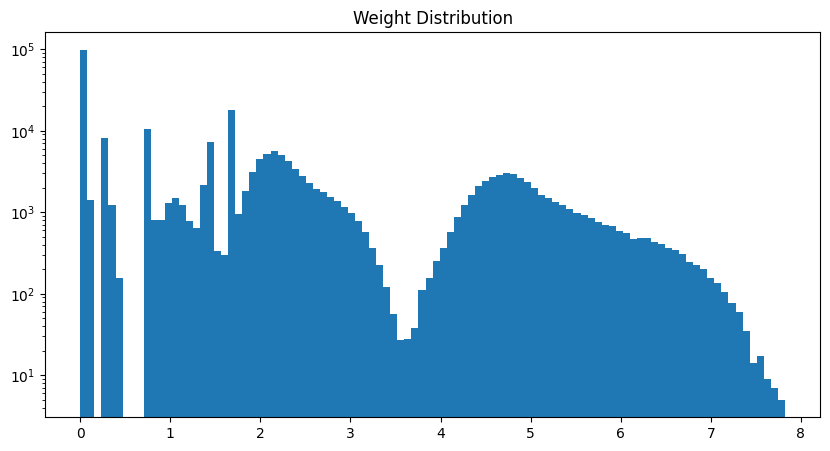

          count      mean       std       min       25%       50%       75%  \
Label                                                                         
b      164333.0  2.501018  1.794235  0.064061  1.340468  2.080362  4.353313   
s       85667.0  0.008078  0.008231  0.001502  0.001503  0.001503  0.018636   

            max  
Label            
b      7.822543  
s      0.018636  


In [36]:

print(df["Weight"].describe())

plt.figure(figsize=(10,5))

plt.hist(
    df["Weight"],
    bins=100
)

plt.yscale("log")

plt.title("Weight Distribution")
plt.savefig(
    "/Users/mahdikhosravi/Downloads/weight_distribution.png",
    bbox_inches="tight"
)
plt.show()

print(
    df.groupby("Label")["Weight"].describe()
)

PRI_jet_num
0    99913
1    77544
2    50379
3    22164
Name: count, dtype: int64
PRI_jet_num
0    0.399652
1    0.310176
2    0.201516
3    0.088656
Name: proportion, dtype: float64


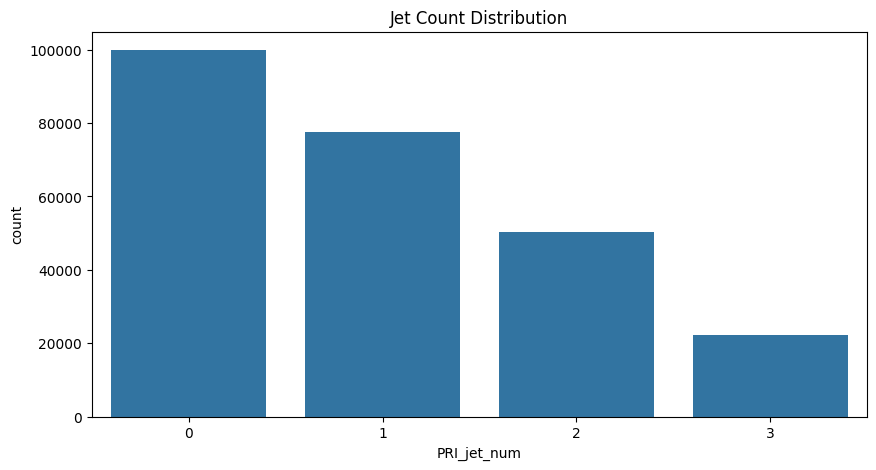

In [37]:
print(
    df["PRI_jet_num"]
    .value_counts()
    .sort_index()
)

print(
    df["PRI_jet_num"]
    .value_counts(normalize=True)
    .sort_index()
)

sns.countplot(
    data=df,
    x="PRI_jet_num"
)

plt.title("Jet Count Distribution")
plt.savefig(
    "/Users/mahdikhosravi/Downloads/jet_count_distribution.png",
    bbox_inches="tight"
)
plt.show()

In [8]:

df_model = df.replace(-999, np.nan)

In [9]:
# =====================================================
# 8. Feature Engineering
# =====================================================

df_model["MMC_missing"] = (
    df["DER_mass_MMC"] == -999
).astype(int)

df_model["LeadingJet_missing"] = (
    df["PRI_jet_leading_pt"] == -999
).astype(int)

df_model["SubleadingJet_missing"] = (
    df["PRI_jet_subleading_pt"] == -999
).astype(int)

df_model["has_jet"] = (
    df["PRI_jet_num"] > 0
).astype(int)

df_model["has_two_jets"] = (
    df["PRI_jet_num"] >= 2
).astype(int)

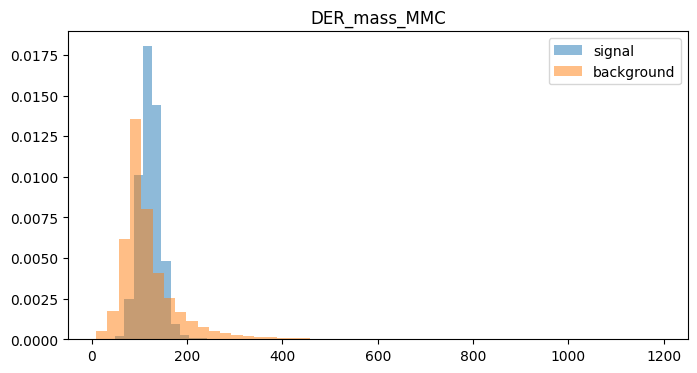

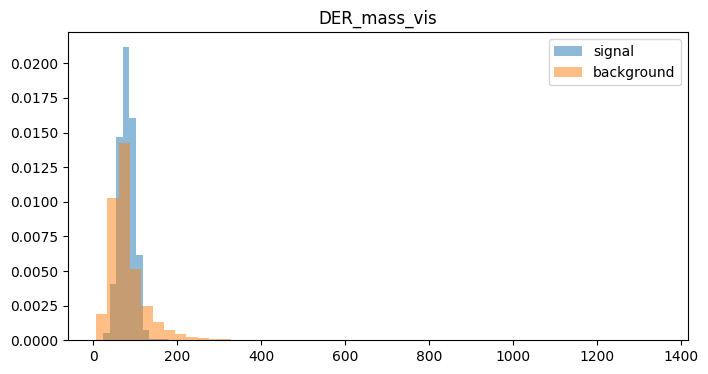

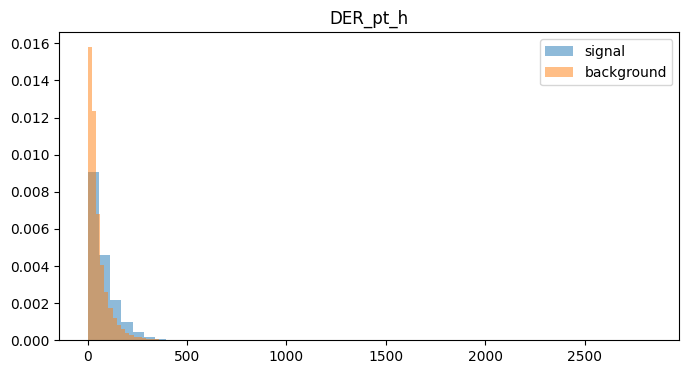

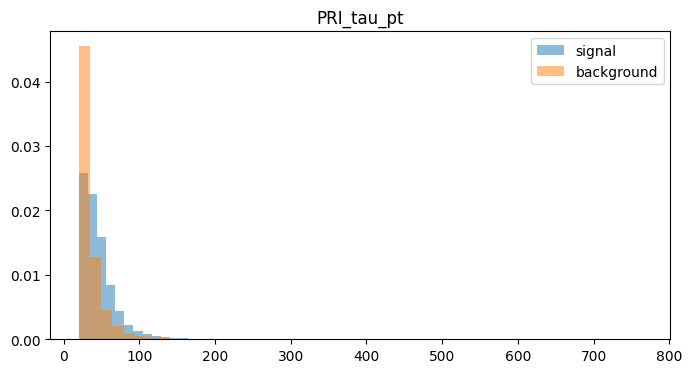

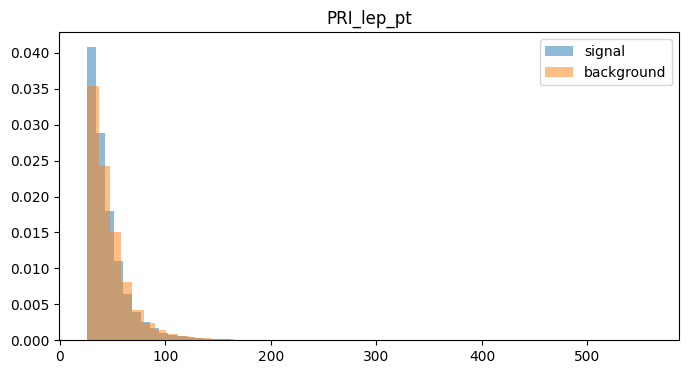

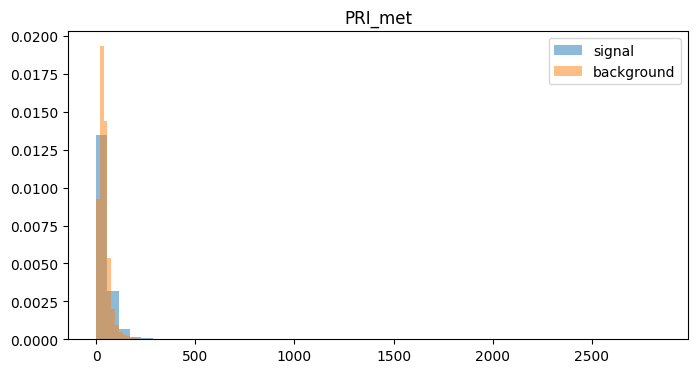

In [38]:

# =====================================================
# 9. Feature Distributions
# =====================================================

features = [
    "DER_mass_MMC",
    "DER_mass_vis",
    "DER_pt_h",
    "PRI_tau_pt",
    "PRI_lep_pt",
    "PRI_met"
]

for col in features:

    plt.figure(figsize=(8,4))

    signal = df_model[
        df_model["Label"] == "s"
    ][col]

    background = df_model[
        df_model["Label"] == "b"
    ][col]

    plt.hist(
        signal.dropna(),
        bins=50,
        density=True,
        alpha=0.5,
        label="signal"
    )

    plt.hist(
        background.dropna(),
        bins=50,
        density=True,
        alpha=0.5,
        label="background"
    )

    plt.title(col)
    plt.legend()
    plt.savefig(
        f"/Users/mahdikhosravi/Downloads/{col}_distribution.png",
        bbox_inches="tight"
    )
    
    plt.show()

In [11]:
# =====================================================
# 10. Correlation with Target
# =====================================================

tmp = df_model.copy()

tmp["Label"] = (
    tmp["Label"] == "s"
).astype(int)

corr_target = (
    tmp.corr(numeric_only=True)["Label"]
    .sort_values(
        key=np.abs,
        ascending=False
    )
)

display(corr_target.head(20))

Label                          1.000000
Weight                        -0.630982
DER_mass_transverse_met_lep   -0.351428
DER_deltaeta_jet_jet           0.328224
DER_mass_jet_jet               0.316727
DER_lep_eta_centrality         0.308082
DER_prodeta_jet_jet           -0.294340
DER_met_phi_centrality         0.271752
MMC_missing                   -0.239751
PRI_tau_pt                     0.235238
DER_pt_ratio_lep_tau          -0.195398
DER_pt_h                       0.192526
DER_sum_pt                     0.153236
has_jet                        0.150469
LeadingJet_missing            -0.150469
has_two_jets                   0.141264
SubleadingJet_missing         -0.141264
PRI_met_sumet                  0.135520
PRI_jet_all_pt                 0.134296
PRI_jet_num                    0.133549
Name: Label, dtype: float64

In [12]:
# =====================================================
# 11. Prepare ML Data
# =====================================================

X = df_model.drop(
    columns=[
        "EventId",
        "Weight",
        "Label"
    ]
)

y = (
    df_model["Label"] == "s"
).astype(int)

w = df_model["Weight"]

In [13]:
from sklearn.model_selection import StratifiedKFold

folds = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []

for fold, (tr_idx, val_idx) in enumerate(
    folds.split(X, y)
):

    X_tr = X.iloc[tr_idx]
    X_val = X.iloc[val_idx]

    y_tr = y.iloc[tr_idx]
    y_val = y.iloc[val_idx]

    w_tr = w.iloc[tr_idx]
    w_val = w.iloc[val_idx]

    model = LGBMClassifier(
        objective="binary",
        n_estimators=3000,
        learning_rate=0.02,
        num_leaves=127,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(
        X_tr,
        y_tr,
        sample_weight=w_tr
    )

    pred = model.predict_proba(X_val)[:,1]

    score = roc_auc_score(
        y_val,
        pred,
        sample_weight=w_val
    )

    scores.append(score)

    print(
        f"Fold {fold+1}: {score:.5f}"
    )

print("\nMean:", np.mean(scores))
print("Std :", np.std(scores))

[LightGBM] [Info] Number of positive: 68533, number of negative: 131467
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003516 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7397
[LightGBM] [Info] Number of data points in the train set: 200000, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001682 -> initscore=-6.385864
[LightGBM] [Info] Start training from score -6.385864
Fold 1: 0.92886
[LightGBM] [Info] Number of positive: 68533, number of negative: 131467
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003528 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7398
[LightGBM] [Info] Number of data points in the train set: 200000, number of used features: 3

,feature,importance
0,DER_mass_MMC,23632
19,PRI_met,20004
1,DER_mass_transverse_met_lep,19904
2,DER_mass_vis,19013
14,PRI_tau_eta,18821
21,PRI_met_sumet,18671
15,PRI_tau_phi,18443
7,DER_deltar_tau_lep,18339
13,PRI_tau_pt,18325
17,PRI_lep_eta,18252


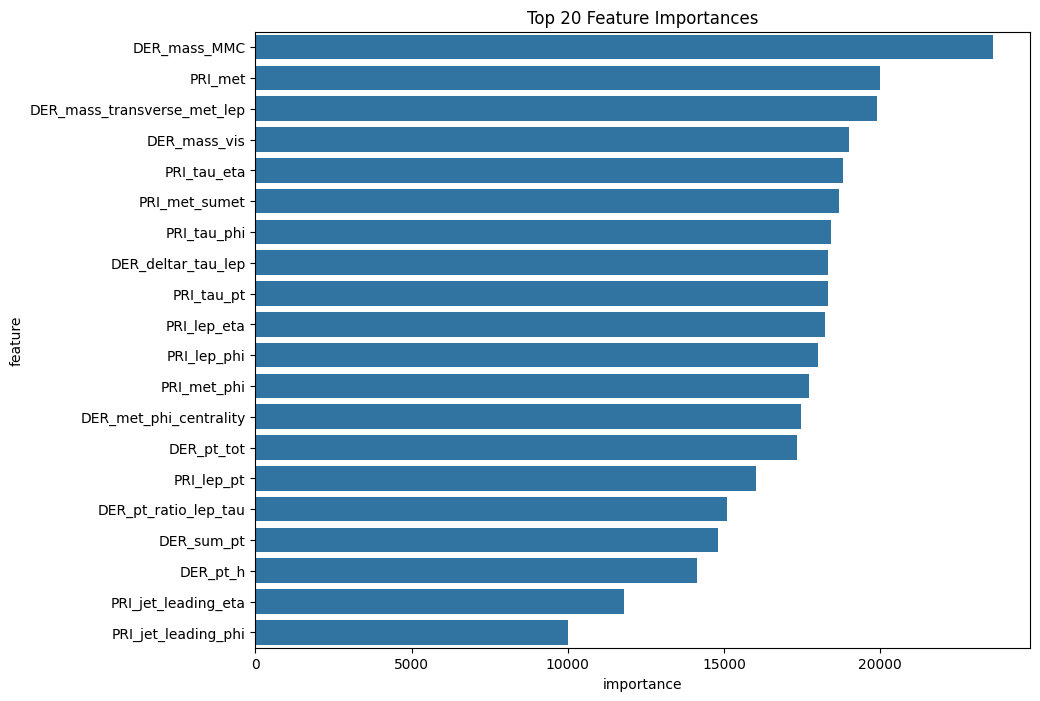

In [39]:
# =====================================================
# 15. Feature Importance
# =====================================================

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

display(
    importance.head(20)
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(20),
    x="importance",
    y="feature"
)

plt.title(
    "Top 20 Feature Importances"
)

plt.savefig(
    "/Users/mahdikhosravi/Downloads/feature_importance.png",
    bbox_inches="tight"
)
plt.show()

In [15]:
# =====================================================
# 16. Save Model (Optional)
# =====================================================

import joblib

joblib.dump(
    model,
    "Higgs_particle_model.pkl"
)

print("Model saved.")

Model saved.


In [18]:
proba = model.predict_proba(X)[:,1]
results = pd.DataFrame({
    "TrueLabel": y,
    "SignalProbability": proba
})

display(results.head())

,TrueLabel,SignalProbability
0,1,0.042275
1,0,0.001118
2,0,0.000158
3,0,0.000161
4,0,0.000050


In [19]:
pred = (proba > 0.5).astype(int)

from sklearn.metrics import classification_report

print(classification_report(y, pred))

              precision    recall  f1-score   support

           0       0.77      1.00      0.87    164333
           1       0.99      0.43      0.60     85667

    accuracy                           0.80    250000
   macro avg       0.88      0.71      0.73    250000
weighted avg       0.84      0.80      0.78    250000



In [25]:
sample_X = X.sample(
    5000,
    random_state=42
)

In [26]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(sample_X)

/opt/miniconda3/envs/pytorch_env/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


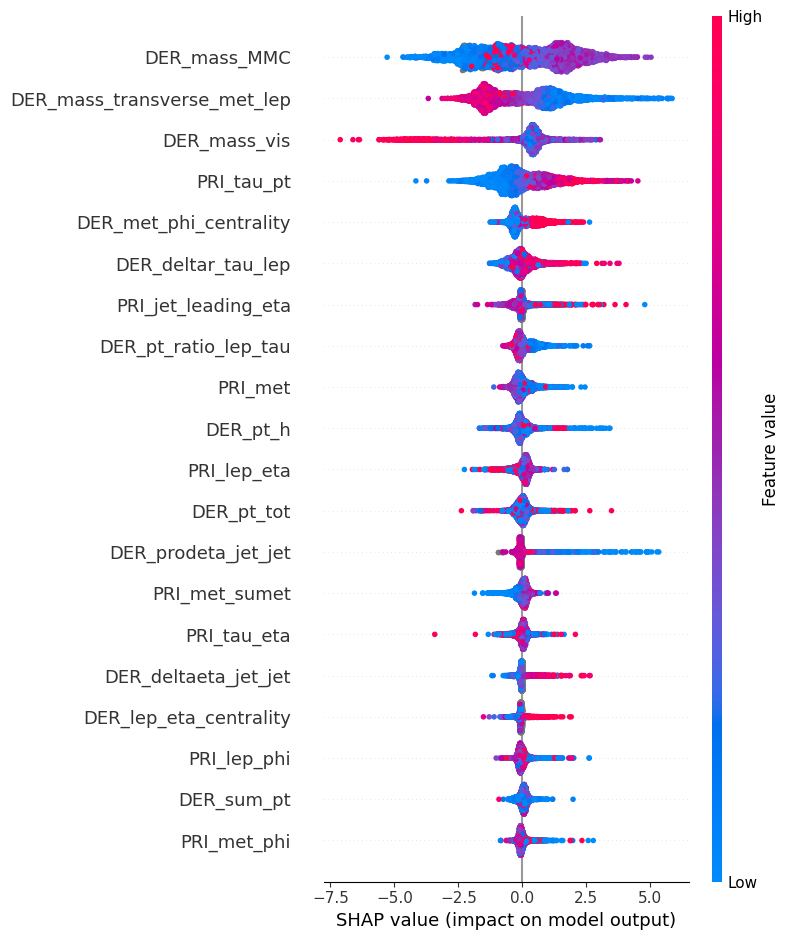

In [41]:
shap.summary_plot(
    shap_values,
    sample_X,
    show=False
)
plt.savefig(
    "/Users/mahdikhosravi/Downloads/shap_summary.png",
    bbox_inches="tight"
)